In [1]:
## Set up libraries and functions
import numpy as np
from scipy.stats import multivariate_t
from scipy.linalg import sqrtm as sqrtmat

np.random.seed(0)

def generate_gaussian_vectors(num_vectors, dimensions):
  """Generates standard multivariate Gaussian random vectors.

  Args:
    num_vectors: The number of vectors to generate.
    dimensions: The dimensionality of each vector.

  Returns:
    A NumPy array of shape (num_vectors, dimensions) containing the generated vectors.
  """
  return np.random.normal(size=(num_vectors, dimensions))

def generate_multivariate_t_vectors(num_vectors, dimensions, loc=None, shape=None, df=3):
    """Generates multivariate t random vectors.

    Args:
        num_vectors: The number of vectors to generate.
        dimensions: The dimensionality of each vector.
        loc: The location parameter. Defaults to a zero vector.
        shape: The scale matrix. Defaults to an identity matrix.
        df: Degrees of freedom.

    Returns:
        A NumPy array of shape (num_vectors, dimensions) containing the generated vectors.
    """
    if loc is None:
        loc = np.zeros(dimensions)
    if shape is None:
        shape = np.eye(dimensions)

    return multivariate_t.rvs(loc=loc, shape=shape, df=df, size=num_vectors)

def frechet_distance_normal(features1, features2):
    """Computes the Fréchet distance between two normal distributions.

    Args:
        mean1: Mean vector of the first normal distribution.
        cov1: Covariance matrix of the first normal distribution.
        mean2: Mean vector of the second normal distribution.
        cov2: Covariance matrix of the second normal distribution.

    Returns:
        The Fréchet distance between the two normal distributions.
    """

    mu1 = np.mean(features1, axis=0)
    mu2 = np.mean(features2, axis=0)
    sigma1 = np.cov(features1, rowvar=False)
    sigma2 = np.cov(features2, rowvar=False)

    diff = mu1 - mu2
    covmean= sqrtmat(np.matmul(sigma1, sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = np.sqrt(np.sum(diff**2) + np.trace(sigma1 + sigma2 - 2 * covmean))
    return fid

def estimate_characteristic_function(features, t):
    """Estimates the characteristic function at a given point t.

    Args:
        features: A NumPy array of shape (num_samples, num_dimensions) representing the data.
        t: A scalar representing the point at which to evaluate the characteristic function.

    Returns:
        A NumPy array of shape (num_dimensions,) containing the estimated characteristic function values at each feature dimension.
    """

    num_samples, num_dimensions = features.shape
    characteristic_function_values = np.zeros(num_dimensions, dtype = np.complex_)

    for j in range(num_dimensions):
        characteristic_function_values[j] = np.mean(np.exp(1j * features[:, j]* t))

    return characteristic_function_values

def report_stats(data):
    """
    Calculates and reports the sample mean and standard error of a Python list.

    Args:
        data: A list or numpy array of numerical data.

    Returns:
        A tuple containing the sample mean and standard error.
    """
    data_array = np.array(data)  # Convert to numpy array for efficient calculations
    sample_mean = np.mean(data_array)
    standard_error = np.std(data_array) / np.sqrt(len(data_array))
    print(sample_mean, standard_error)
    return sample_mean, standard_error

In [ ]:
## Compute ECS at t = 1 and 0.5 for Gaussian vs 5 other t distributions and another Gaussian baseline
## Repeated 5 times to obtain mean/sd estimates
np.random.seed(0)
num_samples = 1000000
p = 32
num_iterations = 5

gvt_21_t1_results = []
gvt_3_t1_results = []
gvt_5_t1_results = []
gvt_10_t1_results = []
gvt_100_t1_results = []


gvt_21_thalf_results = []
gvt_3_thalf_results = []
gvt_5_thalf_results = []
gvt_10_thalf_results = []
gvt_100_thalf_results = []

for _ in range(num_iterations):
    gauss_vecs = generate_gaussian_vectors(num_samples, p)
    multi_t_vecs_21 = generate_multivariate_t_vectors(num_samples, p, df = 2.01, shape = 0.01/2.01 * np.identity(p))
    multi_t_vecs_3 = generate_multivariate_t_vectors(num_samples, p, df = 3, shape = 1/3 * np.identity(p))
    multi_t_vecs_5 = generate_multivariate_t_vectors(num_samples, p, df = 5, shape = 3/5 * np.identity(p))
    multi_t_vecs_10 = generate_multivariate_t_vectors(num_samples, p, df = 10, shape = 8/10* np.identity(p))
    multi_t_vecs_100 = generate_multivariate_t_vectors(num_samples, p, df = 100, shape = 98/100* np.identity(p))

    t = 1

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_21, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_21_t1_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_3, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_3_t1_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_5, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_5_t1_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_10, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_10_t1_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_100, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_100_t1_results.append(average_norm / t)

    t = 0.5

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_21, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_21_thalf_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_3, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_3_thalf_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_5, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_5_thalf_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_10, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_10_thalf_results.append(average_norm / t)

    characteristic_gaussian = estimate_characteristic_function(gauss_vecs, t)
    characteristic_multi_t = estimate_characteristic_function(multi_t_vecs_100, t)
    difference = characteristic_gaussian - characteristic_multi_t
    norms = np.abs(difference)
    average_norm = np.mean(norms)
    gvt_100_thalf_results.append(average_norm / t)


In [ ]:
report_stats(gvt_21_t1_results)
report_stats(gvt_3_t1_results)
report_stats(gvt_5_t1_results)
report_stats(gvt_10_t1_results)
report_stats(gvt_100_t1_results)

report_stats(gvt_21_thalf_results)
report_stats(gvt_3_thalf_results)
report_stats(gvt_5_thalf_results)
report_stats(gvt_10_thalf_results)
report_stats(gvt_100_thalf_results)


0.3790536197191727 4.536201272509218e-05
0.12915649272985927 0.00010049239538493448
0.05380801982298437 7.235271138118314e-05
0.02030820766222131 5.7107388770970976e-05
0.0017324710574015037 5.733136123476409e-05
0.2261333747582536 4.493198179151654e-05
0.05458088580233271 0.00013513837544617673
0.015186702516489506 3.422233680557049e-05
0.004468474085829188 4.772521629431106e-05
0.0010368868351184096 5.2076780768253396e-05


(0.0010368868351184096, 5.2076780768253396e-05)

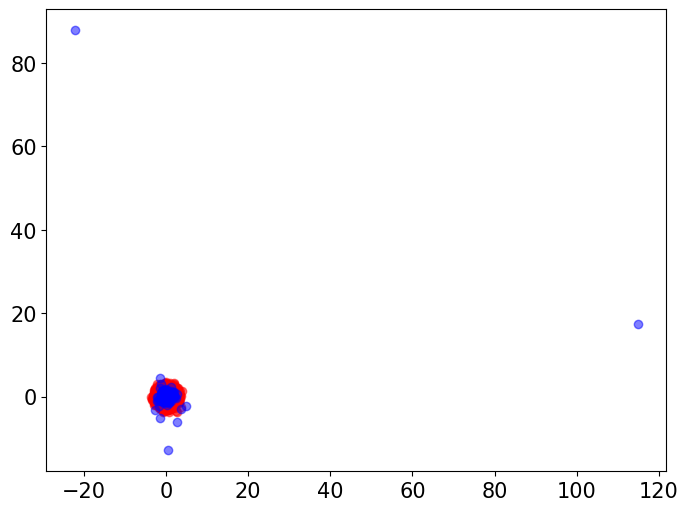

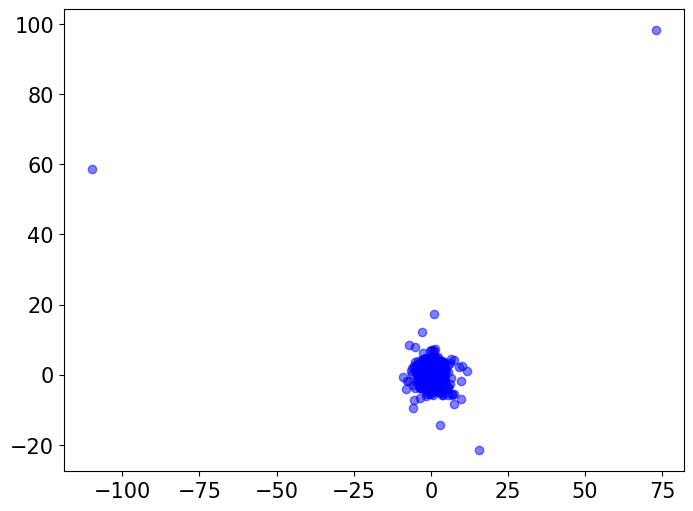

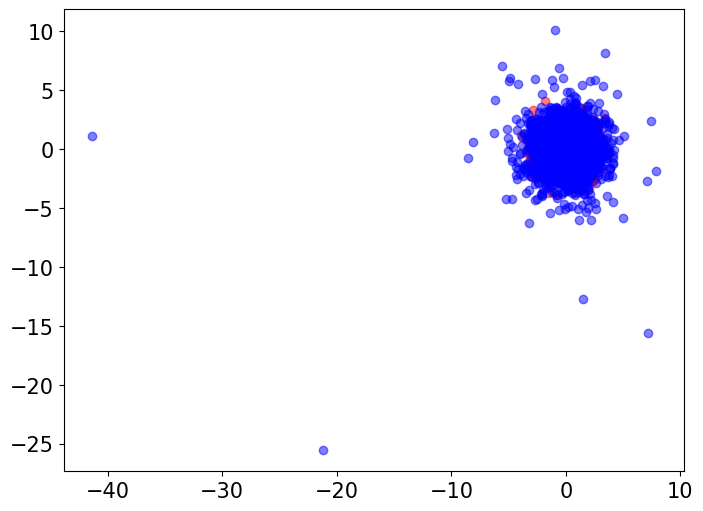

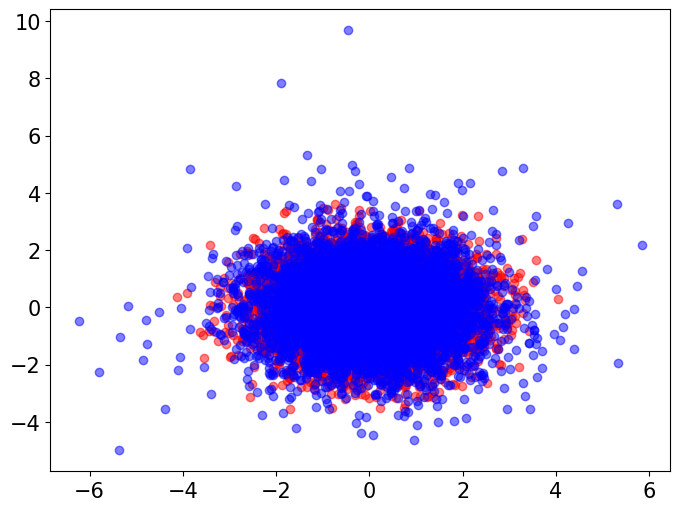

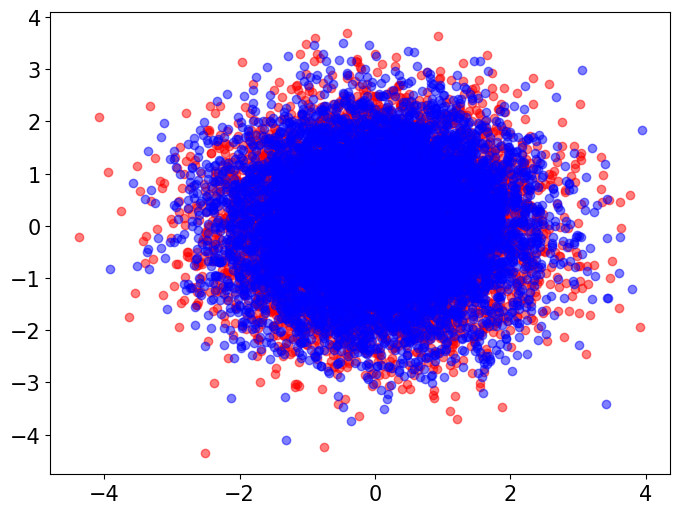

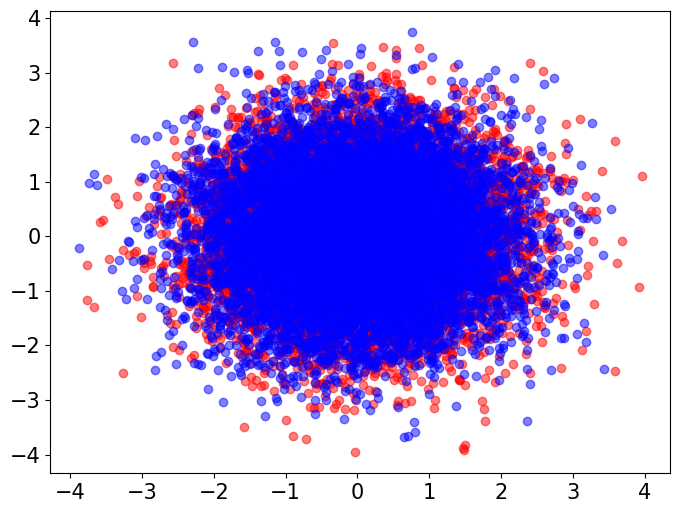

In [ ]:
## PCA visualization of Gaussian and t distributions

import numpy as np
from scipy.stats import multivariate_t
from scipy.linalg import sqrtm as sqrtmat
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(0)

num_samples = 10000  # Reduced for faster plotting
p = 32

gauss_vecs = generate_gaussian_vectors(num_samples, p)
multi_t_vecs_21 = generate_multivariate_t_vectors(num_samples, p, df = 2.01, shape = 0.01/2.01 * np.identity(p))
multi_t_vecs_3 = generate_multivariate_t_vectors(num_samples, p, df = 3, shape = 1/3 * np.identity(p))
multi_t_vecs_5 = generate_multivariate_t_vectors(num_samples, p, df = 5, shape = 3/5 * np.identity(p))
multi_t_vecs_10 = generate_multivariate_t_vectors(num_samples, p, df = 10, shape = 8/10* np.identity(p))
multi_t_vecs_100 = generate_multivariate_t_vectors(num_samples, p, df = 100, shape = 98/100* np.identity(p))
gauss_vecs2 = generate_gaussian_vectors(num_samples, p)

### df = 2.01
# Concatenate the data
combined_data = np.concatenate((gauss_vecs, multi_t_vecs_21), axis=0)

# Apply PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_data)

# Separate the PCA components for plotting
gauss_pca = combined_pca[:num_samples]
multi_t_pca = combined_pca[num_samples:]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(gauss_pca[:, 0], gauss_pca[:, 1], color='red', label='Gaussian Samples', alpha=0.5)
plt.scatter(multi_t_pca[:, 0], multi_t_pca[:, 1], color='blue', label='Multivariate t Samples (df=2.01)', alpha=0.5)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("gauss_v_21.png", bbox_inches='tight')


### df = 3
# Concatenate the data
combined_data = np.concatenate((gauss_vecs, multi_t_vecs_3), axis=0)

# Apply PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_data)

# Separate the PCA components for plotting
gauss_pca = combined_pca[:num_samples]
multi_t_pca = combined_pca[num_samples:]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(gauss_pca[:, 0], gauss_pca[:, 1], color='red', label='Gaussian Samples', alpha=0.5)
plt.scatter(multi_t_pca[:, 0], multi_t_pca[:, 1], color='blue', label='Multivariate t Samples (df=2.01)', alpha=0.5)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("gauss_v_3.png", bbox_inches='tight')

### df = 5
# Concatenate the data
combined_data = np.concatenate((gauss_vecs, multi_t_vecs_5), axis=0)

# Apply PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_data)

# Separate the PCA components for plotting
gauss_pca = combined_pca[:num_samples]
multi_t_pca = combined_pca[num_samples:]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(gauss_pca[:, 0], gauss_pca[:, 1], color='red', label='Gaussian Samples', alpha=0.5)
plt.scatter(multi_t_pca[:, 0], multi_t_pca[:, 1], color='blue', label='Multivariate t Samples (df=2.01)', alpha=0.5)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("gauss_v_5.png", bbox_inches='tight')

### df = 10
# Concatenate the data
combined_data = np.concatenate((gauss_vecs, multi_t_vecs_10), axis=0)

# Apply PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_data)

# Separate the PCA components for plotting
gauss_pca = combined_pca[:num_samples]
multi_t_pca = combined_pca[num_samples:]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(gauss_pca[:, 0], gauss_pca[:, 1], color='red', label='Gaussian Samples', alpha=0.5)
plt.scatter(multi_t_pca[:, 0], multi_t_pca[:, 1], color='blue', label='Multivariate t Samples (df=2.01)', alpha=0.5)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("gauss_v_10.png", bbox_inches='tight')

### df = 100
# Concatenate the data
combined_data = np.concatenate((gauss_vecs, multi_t_vecs_100), axis=0)

# Apply PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_data)

# Separate the PCA components for plotting
gauss_pca = combined_pca[:num_samples]
multi_t_pca = combined_pca[num_samples:]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(gauss_pca[:, 0], gauss_pca[:, 1], color='red', label='Gaussian Samples', alpha=0.5)
plt.scatter(multi_t_pca[:, 0], multi_t_pca[:, 1], color='blue', label='Multivariate t Samples (df=2.01)', alpha=0.5)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("gauss_v_100.png", bbox_inches='tight')

### gauss vs gauss
# Concatenate the data
combined_data = np.concatenate((gauss_vecs, gauss_vecs2), axis=0)

# Apply PCA
pca = PCA(n_components=2)
combined_pca = pca.fit_transform(combined_data)

# Separate the PCA components for plotting
gauss_pca = combined_pca[:num_samples]
gauss_pca2 = combined_pca[num_samples:]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(gauss_pca[:, 0], gauss_pca[:, 1], color='red', label='Gaussian Samples', alpha=0.5)
plt.scatter(gauss_pca2[:, 0], gauss_pca2[:, 1], color='blue', label='Multivariate t Samples (df=2.01)', alpha=0.5)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("gauss_v_gauss.png", bbox_inches='tight')